In [28]:
#import necessary libraries
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
weather_df = pd.read_csv("Nairobi 2023-2025.csv")

In [ ]:
weather_df.info()

In [13]:
weather_df.shape

(822, 14)

In [14]:
weather_df.isnull().sum()

datetime            0
tempmax             0
tempmin             0
temp                0
dew                 0
humidity            0
precip              0
windspeed           0
windspeedmax        0
windspeedmin        0
winddir             0
sealevelpressure    0
cloudcover          0
visibility          0
dtype: int64

In [30]:
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
weather_df.set_index('datetime', inplace=True)
weather_df = weather_df.sort_index()

In [16]:
weather_df['year'] = weather_df['datetime'].dt.year

In [31]:
weather_df

,tempmax,tempmin,temp,dew,humidity,precip,windspeed,windspeedmax,windspeedmin,winddir,sealevelpressure,cloudcover,visibility,year,month,season
datetime,,,,,,,,,,,,,,,,
2023-01-01,26.0,14.8,20.1,10.6,56.7,0.0,36.2,36.2,0.5,75.5,1022.6,51.6,10.3,2023,1,Jan-Mar (Dry)
2023-01-02,23.0,14.8,18.5,11.8,66.2,0.0,36.5,36.5,1.3,75.5,1022.2,66.4,10.3,2023,1,Jan-Mar (Dry)
2023-01-03,22.1,16.0,18.5,14.0,76.1,0.0,38.3,38.3,1.7,73.0,1022.5,75.1,10.0,2023,1,Jan-Mar (Dry)
2023-01-04,21.1,16.0,17.9,14.2,80.1,0.0,27.7,27.7,1.1,68.3,1022.4,83.6,10.1,2023,1,Jan-Mar (Dry)
2023-01-05,24.0,14.9,18.6,11.3,65.5,0.0,31.7,31.7,1.1,54.1,1022.0,70.8,10.1,2023,1,Jan-Mar (Dry)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-28,23.7,17.0,19.1,15.7,81.7,4.0,13.4,13.4,0.0,77.8,1017.6,88.8,17.1,2025,3,Apr-Jun (Long Rains)
2025-03-29,25.1,15.7,20.0,15.1,75.6,0.9,19.6,19.6,0.9,60.8,1018.4,91.3,17.4,2025,3,Apr-Jun (Long Rains)
2025-03-30,26.0,17.9,20.9,15.1,71.4,3.0,23.5,23.5,0.5,84.6,1021.4,88.2,12.0,2025,3,Apr-Jun (Long Rains)


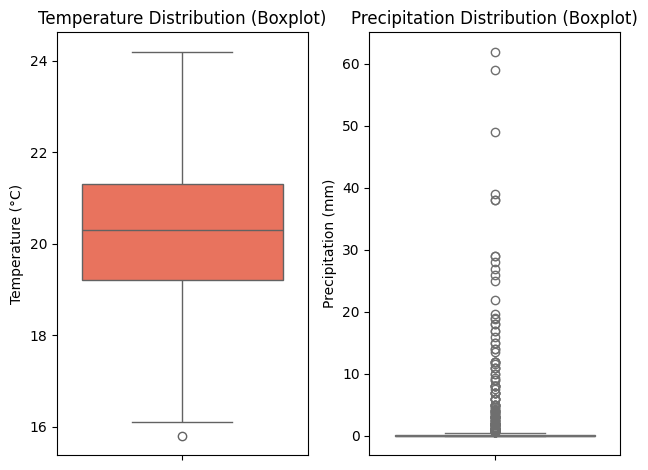

In [19]:
# Temperature boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=weather_df['temp'], color='tomato')
plt.title('Temperature Distribution (Boxplot)')
plt.ylabel('Temperature (°C)')

# Precipitation boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=weather_df['precip'], color='skyblue')
plt.title('Precipitation Distribution (Boxplot)')
plt.ylabel('Precipitation (mm)')

plt.tight_layout()
plt.show()

In [22]:
# Create month and season columns
weather_df['month'] = weather_df['datetime'].dt.month
weather_df['season'] = weather_df['datetime'].dt.month % 12 // 3 + 1  # Season mapping
season_map = {1: 'Jan-Mar (Dry)', 2: 'Apr-Jun (Long Rains)', 3: 'Jul-Sep (Cool Dry)', 4: 'Oct-Dec (Short Rains)'}
weather_df['season'] = weather_df['season'].map(season_map)


In [24]:
weather_df

,datetime,tempmax,tempmin,temp,dew,humidity,precip,windspeed,windspeedmax,windspeedmin,winddir,sealevelpressure,cloudcover,visibility,year,month,season
0,2023-01-01,26.0,14.8,20.1,10.6,56.7,0.0,36.2,36.2,0.5,75.5,1022.6,51.6,10.3,2023,1,Jan-Mar (Dry)
1,2023-01-02,23.0,14.8,18.5,11.8,66.2,0.0,36.5,36.5,1.3,75.5,1022.2,66.4,10.3,2023,1,Jan-Mar (Dry)
2,2023-01-03,22.1,16.0,18.5,14.0,76.1,0.0,38.3,38.3,1.7,73.0,1022.5,75.1,10.0,2023,1,Jan-Mar (Dry)
3,2023-01-04,21.1,16.0,17.9,14.2,80.1,0.0,27.7,27.7,1.1,68.3,1022.4,83.6,10.1,2023,1,Jan-Mar (Dry)
4,2023-01-05,24.0,14.9,18.6,11.3,65.5,0.0,31.7,31.7,1.1,54.1,1022.0,70.8,10.1,2023,1,Jan-Mar (Dry)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,2025-03-28,23.7,17.0,19.1,15.7,81.7,4.0,13.4,13.4,0.0,77.8,1017.6,88.8,17.1,2025,3,Apr-Jun (Long Rains)
818,2025-03-29,25.1,15.7,20.0,15.1,75.6,0.9,19.6,19.6,0.9,60.8,1018.4,91.3,17.4,2025,3,Apr-Jun (Long Rains)
819,2025-03-30,26.0,17.9,20.9,15.1,71.4,3.0,23.5,23.5,0.5,84.6,1021.4,88.2,12.0,2025,3,Apr-Jun (Long Rains)
820,2025-03-31,24.9,17.0,19.4,15.7,80.4,0.4,27.5,27.5,0.9,88.3,1021.4,74.9,10.5,2025,3,Apr-Jun (Long Rains)


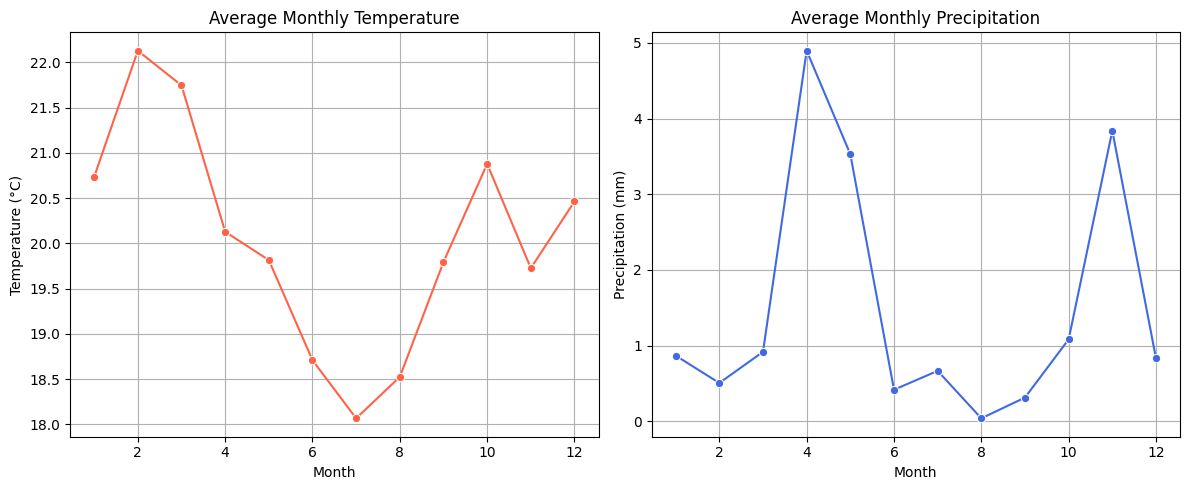

In [32]:
# Monthly average temp & precipitation
monthly_avg = weather_df.groupby('month')[['temp', 'precip']].mean().reset_index()

plt.figure(figsize=(12, 5))

# Temperature trend
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_avg, x='month', y='temp', marker='o', color='tomato')
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True)

# Precipitation trend
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_avg, x='month', y='precip', marker='o', color='royalblue')
plt.title('Average Monthly Precipitation')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.grid(True)

plt.tight_layout()
plt.show()

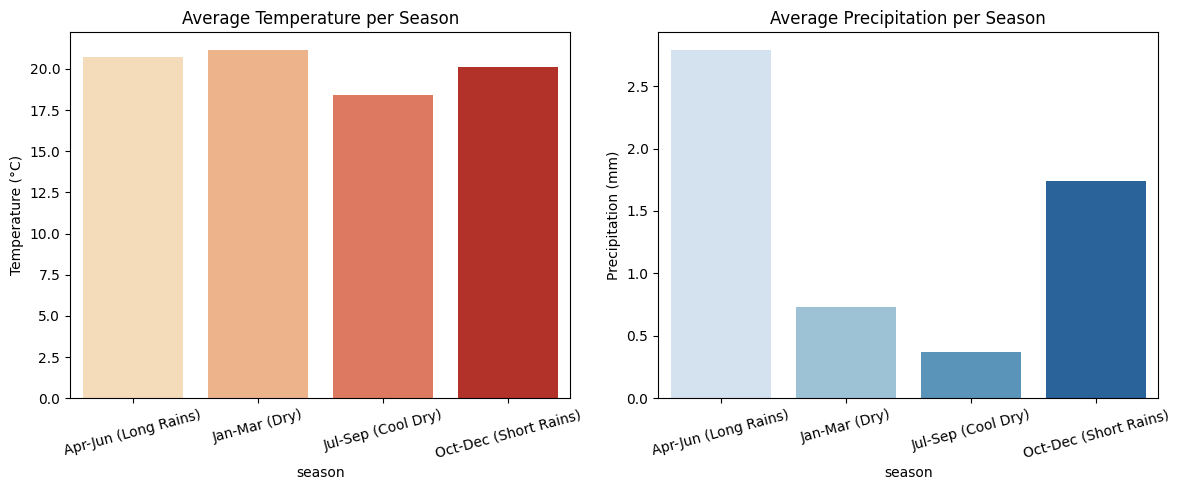

In [33]:
# Seasonal average temp & precipitation
seasonal_avg = weather_df.groupby('season')[['temp', 'precip']].mean().reset_index()

plt.figure(figsize=(12, 5))

# Temperature by season
plt.subplot(1, 2, 1)
sns.barplot(data=seasonal_avg, x='season', y='temp' , hue = 'season', palette='OrRd' , legend = False)
plt.title('Average Temperature per Season')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=15)

# Precipitation by season
plt.subplot(1, 2, 2)
sns.barplot(data=seasonal_avg, x='season', y='precip', palette='Blues',hue = 'season' , legend = False)
plt.title('Average Precipitation per Season')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [34]:
# Feature selection
features = ['temp', 'precip']  # adjust to match your column names
data = weather_df[features]

In [35]:
data

,temp,precip
datetime,,
2023-01-01,20.1,0.0
2023-01-02,18.5,0.0
2023-01-03,18.5,0.0
2023-01-04,17.9,0.0
2023-01-05,18.6,0.0
...,...,...
2025-03-28,19.1,4.0
2025-03-29,20.0,0.9
2025-03-30,20.9,3.0


In [40]:
# the function scales all feature values to a fixed range, usually 0 to 1.
scaler = MinMaxScaler()
# Calculates the min and max values in your dataset (using .fit) and Applies the transformation
scaled_data = scaler.fit_transform(data)

In [42]:
scaled_data

array([[0.51190476, 0.        ],
       [0.32142857, 0.        ],
       [0.32142857, 0.        ],
       ...,
       [0.60714286, 0.0483871 ],
       [0.42857143, 0.00645161],
       [0.53571429, 0.00645161]])

<Axes: title={'center': 'Temperature & Precipitation Over Time'}, xlabel='datetime'>

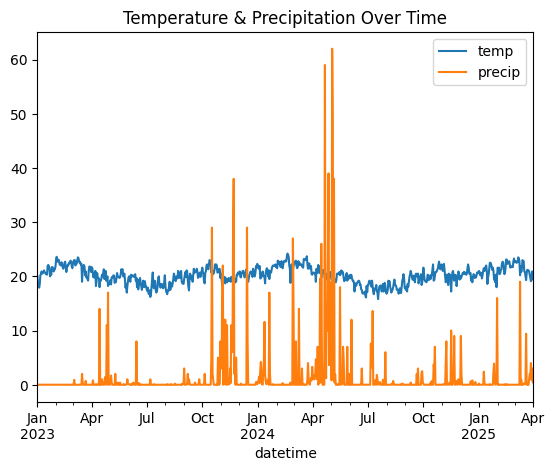

In [44]:
weather_df[['temp', 'precip']].plot(title="Temperature & Precipitation Over Time")

In [46]:
#Create Sequences for Multivariate Input

def create_multivariate_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])         # Shape: (time_steps, features)
        y.append(data[i+time_steps])           # Predict both temp & rainfall
    return np.array(X), np.array(y)

In [52]:
# Convert to NumPy array
data_array = data.values

# Create sequences
X, y = create_multivariate_sequences(data_array, time_steps=30)

# Reshape for LSTM
print("X shape:", X.shape)  # should be (samples, 30, 2)
print("y shape:", y.shape)  # should be (samples, 2)


X shape: (792, 30, 2)
y shape: (792, 2)


In [59]:
# Build a multivariate LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(LSTM(32))
model.add(Dense(2))  # 2 outputs: temperature and rainfall
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 30, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,634 (115.76 KB)

 Trainable params: 29,634 (115.76 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 181.1399 - val_loss: 141.0795
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 119.6964 - val_loss: 99.9008
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 95.5226 - val_loss: 83.4050
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 74.5269 - val_loss: 72.9439
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 66.5148 - val_loss: 64.4666
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 67.8782 - val_loss: 57.1067
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 60.9276 - val_loss: 50.6450
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 44.8383 - val_loss: 44.9159
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 39.8502 - val_loss: 39.8378
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 34.8950 - val_loss: 35.4009
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 35.7722 - val_loss: 31.4786
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━

In [61]:
# Assume your trained model is called `model`
# Assume `data` is your normalized DataFrame
# We'll use the last `time_steps` of data to predict forward

def forecast_sequence(model, data, time_steps=30, forecast_horizon=7):
    """
    Forecast next `forecast_horizon` steps using a rolling prediction approach.
    """
    predictions = []

    # Start with the last time_steps from the normalized data
    current_batch = data[-time_steps:].values.reshape(1, time_steps, -1)

    for _ in range(forecast_horizon):
        # Predict next step
        pred = model.predict(current_batch, verbose=0)[0]
        predictions.append(pred)

        # Update the current batch (rolling window)
        current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

    return np.array(predictions)

In [69]:
# 7 day forecast
forecast_7_day = forecast_sequence(model, data, time_steps=30, forecast_horizon=7)

# Monthly forecast
forecast_30_day = forecast_sequence(model, data, time_steps=30, forecast_horizon=30)

In [71]:
# 7 day predictions
forecast_7_day

array([[17.642992 ,  1.5228728],
       [17.643038 ,  1.5228863],
       [17.643045 ,  1.5228877],
       [17.643047 ,  1.5228887],
       [17.64305  ,  1.5228891],
       [17.643051 ,  1.5228887],
       [17.643051 ,  1.5228887]], dtype=float32)

In [85]:
# 30 day Predictions
forecast_30_day

array([[17.642992 ,  1.5228728],
       [17.643038 ,  1.5228863],
       [17.643045 ,  1.5228877],
       [17.643047 ,  1.5228887],
       [17.64305  ,  1.5228891],
       [17.643051 ,  1.5228887],
       [17.643051 ,  1.5228887],
       [17.643051 ,  1.5228888],
       [17.643051 ,  1.5228888],
       [17.643053 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643051 ,  1.522889 ],
       [17.643051 ,  1.5228889],
       [17.643051 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643053 ,  1.522889 ],
       [17.643051 ,  1.522889 ],
       [17.643053 ,  1.5228893],
       [17.643051 ,  1.5228891],
       [17.643051 ,  1.5228891],
       [17.643051 ,  1.5228891],
       [17.643053 ,  1.5228891],
       [17.643051 ,  1.522889 ],
       [17.643051 ,  1.5228891],
       [17.643053 ,  1.5228891],
       [17.643051 ,  1.5228891],
       [17.643051 ,  1.522889 ]], dtype=flo

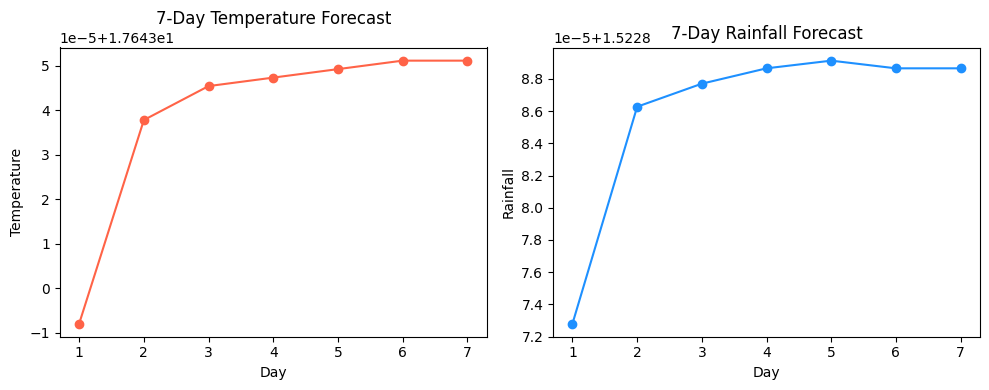

In [84]:
# Visualize the forecast
days = list(range(1, 8))
temperature = forecast_7_day[:, 0]
rainfall = forecast_7_day[:, 1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(days, temperature, marker='o', color='tomato')
plt.title("7-Day Temperature Forecast")
plt.xlabel("Day")
plt.ylabel("Temperature")

plt.subplot(1, 2, 2)
plt.plot(days, rainfall, marker='o', color='dodgerblue')
plt.title("7-Day Rainfall Forecast")
plt.xlabel("Day")
plt.ylabel("Rainfall")

plt.tight_layout()
plt.show()